In [95]:
#ucitavanje potrebnih biblioteka
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ndcg_score, label_ranking_average_precision_score, f1_score, accuracy_score
import time
import scipy.stats as stats

In [96]:
# Ucitavanje podataka

df = pd.read_csv("C:\\Users\\Hp\\Documents\\Formula1\\tables\\trkeDID_pits_over.csv")

# izbaciti redove za koje se ne zna ime i pozicija vozaca
df = df.dropna(subset=["position_race", "race_name"])

# Umesto nan vrednosti stavlja se -1
df["position_quali"] = df["position_quali"].fillna(-1)


# pravimo group id-jeve po sezoni i rundi
df["group_id"] = df["season"].astype(str) + "_" + df["round"].astype(str)

#label enkodovanje imena staze
le = LabelEncoder()
df["circuit"] = le.fit_transform(df["circuit"])
le = LabelEncoder()
df["driverId"] = le.fit_transform(df["driverId"])

# Izbacivanje nepotrebnih kolona
drop_cols = ["status", "driver", "constructor", "_merge",
             "race_name", "total_time_ms", 'laps', 'points', 'num_pit_stops', 'lap_pit_stops', 'duration_pit_stops']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])


# uklanjamo target kolonu i group_id jer se on koristi samo za split 
features = df.drop(columns=["position_race", "group_id"])
target = 21 - df["position_race"]

# Hronoloski split
unique_races_sorted = (
    df[["season", "round", "group_id"]]
    .drop_duplicates()
    .sort_values(["season", "round"])
)["group_id"].values

# Train (70%) / Val (10%) / Test (20%) split
num_races = len(unique_races_sorted)
train_end = int(0.7 * num_races)
val_end = int(0.8 * num_races)

train_races = unique_races_sorted[:train_end]
val_races = unique_races_sorted[train_end:val_end]
test_races = unique_races_sorted[val_end:]

train_mask = df["group_id"].isin(train_races)
val_mask = df["group_id"].isin(val_races)
test_mask = df["group_id"].isin(test_races)

X_train = features[train_mask]
y_train = target[train_mask]
X_val = features[val_mask]
y_val = target[val_mask]
X_test = features[test_mask]
y_test = target[test_mask]

group_sizes_train = df[train_mask].groupby("group_id").size().values
group_sizes_val = df[val_mask].groupby("group_id").size().values
group_sizes_test = df[test_mask].groupby("group_id").size().values



# Pravljenje DMatrix-a

dtrain = xgb.DMatrix(X_train, label=y_train)
dtrain.set_group(group_sizes_train)

dval = xgb.DMatrix(X_val, label=y_val)
dval.set_group(group_sizes_val)

dtest = xgb.DMatrix(X_test, label=y_test)
dtest.set_group(group_sizes_test)




In [97]:
df.columns

Index(['season', 'round', 'drivers_num', 'position_quali', 'position_race',
       'grid', 'driverId', 'circuit', ' lap_length', ' number_of_laps',
       ' number_of_corners', 'AirTemp', 'Humidity', 'Pressure', 'TrackTemp',
       'WindSpeed', 'rain_bin', 'wind_direction', 'is_sprint_weekend',
       'last_year_time', 'avg_position_last5', 'num_dnfs_last5',
       'avg_gained_lost_last5', 'num_overtakes', 'group_id'],
      dtype='object')

In [98]:
#  pronalazenje hiperparametara

def objective(trial):
    params = {
        "objective": "rank:pairwise",
        "eval_metric": "ndcg",
        "eta": trial.suggest_float("eta", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "lambda": trial.suggest_float("lambda", 0, 5),
        "alpha": trial.suggest_float("alpha", 0, 5),
    }

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,
        evals=[(dval, "validation")],
        early_stopping_rounds=10,
        verbose_eval=False
    )

    preds = model.predict(dval)

    df_val_copy = df[val_mask].copy()
    df_val_copy["pred_score"] = preds

    ndcg_list = []
    for _, group in df_val_copy.groupby("group_id"):
        if group.shape[0] < 2:
            continue
        true_rel = 21 - group["position_race"].values
        pred_score = group["pred_score"].values
        ndcg = ndcg_score([true_rel], [pred_score])
        ndcg_list.append(ndcg)

    return np.mean(ndcg_list)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best hyperparameters:")
print(study.best_params)

[I 2025-06-23 21:41:12,174] A new study created in memory with name: no-name-797fc8e5-bd87-4509-a1c9-52a372cc3312
[I 2025-06-23 21:41:12,279] Trial 0 finished with value: 0.9480488896400397 and parameters: {'eta': 0.1724150394782664, 'max_depth': 3, 'min_child_weight': 6, 'gamma': 4.860039916673003, 'subsample': 0.8573185972505925, 'colsample_bytree': 0.8897005296945353, 'lambda': 1.0782522339549767, 'alpha': 3.3874606062255186}. Best is trial 0 with value: 0.9480488896400397.
[I 2025-06-23 21:41:12,370] Trial 1 finished with value: 0.9614072779362096 and parameters: {'eta': 0.15226865666514194, 'max_depth': 5, 'min_child_weight': 2, 'gamma': 0.5090122995902019, 'subsample': 0.7904894671960168, 'colsample_bytree': 0.5958942956174597, 'lambda': 2.535556896953961, 'alpha': 1.06753232614974}. Best is trial 1 with value: 0.9614072779362096.
[I 2025-06-23 21:41:12,461] Trial 2 finished with value: 0.9539101757035084 and parameters: {'eta': 0.18992911941584345, 'max_depth': 5, 'min_child_wei

Best hyperparameters:
{'eta': 0.014188743873864595, 'max_depth': 8, 'min_child_weight': 1, 'gamma': 0.00761074778349502, 'subsample': 0.9934160200281621, 'colsample_bytree': 0.5068060697137164, 'lambda': 0.27480756343578605, 'alpha': 3.0649478574724203}


In [99]:

params = study.best_params
params["objective"] = "rank:pairwise"
params["eval_metric"] = "ndcg"

model = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    evals=[(dval, "validation")],
    early_stopping_rounds=10
)

model.save_model(f"models_camp/xgb_ranker_with_val_{time.time()}.model")

print("Model trained and saved successfully.")


[0]	validation-ndcg:0.73829
[1]	validation-ndcg:0.75431
[2]	validation-ndcg:0.78287
[3]	validation-ndcg:0.81242
[4]	validation-ndcg:0.77162
[5]	validation-ndcg:0.77560
[6]	validation-ndcg:0.83442
[7]	validation-ndcg:0.83533
[8]	validation-ndcg:0.83790
[9]	validation-ndcg:0.83796
[10]	validation-ndcg:0.85031
[11]	validation-ndcg:0.85777
[12]	validation-ndcg:0.84349
[13]	validation-ndcg:0.84547
[14]	validation-ndcg:0.85117
[15]	validation-ndcg:0.84754
[16]	validation-ndcg:0.84284
[17]	validation-ndcg:0.83341
[18]	validation-ndcg:0.83192
[19]	validation-ndcg:0.81662
[20]	validation-ndcg:0.81597
Model trained and saved successfully.


C:\Users\Hp\AppData\Local\Temp\ipykernel_928\3232917596.py:13: UserWarning: [21:41:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  model.save_model(f"models_camp/xgb_ranker_with_val_{time.time()}.model")


In [100]:
# Predvidjanja modela
y_pred_scores = model.predict(dtest)


df_test = df[test_mask].copy()
df_test["pred_score"] = y_pred_scores

df_test['position_race'] = pd.to_numeric(df_test['position_race'], errors='coerce')
df_test['pred_score'] = pd.to_numeric(df_test['pred_score'], errors='coerce')


race_groups = df_test.groupby("group_id")

# Metrike
ndcg_list = []
tau_list = []
spearman_list = []

for race_id, group in race_groups:
    if group.shape[0] < 2:
        continue  # preskacu se trke sa manje od dva vozaca

    true_ranks = group["position_race"].values
    pred_scores = group["pred_score"].values

    # relevantnost 21 - pozicija, jer ndcg ocekuje vece = bolje
    true_relevance = 21 - true_ranks
    ndcg = ndcg_score([true_relevance], [pred_scores])
    ndcg_list.append(ndcg)

    # Kendall's Tau i Spermanova korelacija
    tau, _ = stats.kendalltau(-true_ranks, pred_scores)
    spearman, _ = stats.spearmanr(-true_ranks, pred_scores)
    tau_list.append(tau)
    spearman_list.append(spearman)


print(f"Evaluation Metrics Across Races:")
print(f"Average NDCG: {np.mean(ndcg_list):.4f}")
print(f"Average Kendall's Tau: {np.nanmean(tau_list):.4f}")
print(f"Average Spearman: {np.nanmean(spearman_list):.4f}")


Evaluation Metrics Across Races:
Average NDCG: 0.9621
Average Kendall's Tau: 0.6052
Average Spearman: 0.7492


In [101]:
all_predictions = pd.DataFrame()
for race_id, group in race_groups:
    if group.shape[0] < 2:
        continue  # skip races with fewer than two drivers

    one_race = group[['pred_score']].copy()  
    one_race['pred_rank'] = group['pred_score'].rank(ascending=False, method='first').to_frame()
    one_race['position_race'] = group['position_race']
    all_predictions = pd.concat([all_predictions, one_race])


In [106]:
acc = accuracy_score(all_predictions['position_race'], all_predictions["pred_rank"])
f1 = f1_score(all_predictions['position_race'], all_predictions["pred_rank"], average='weighted')

In [107]:
print(f'Accuracy whole set: {acc}')
print(f'F1 whole set: {f1}')

Accuracy whole set: 0.16423357664233576
F1 whole set: 0.16211521426733863


In [ ]:
#accuracy and f1 
all_predictions = pd.DataFrame()
f1_list, acc_list = [], []
for race_id, group in race_groups:
    if group.shape[0] < 2:
        continue  # preskacu se trke sa manje od dva vozaca

    one_race = group['pred_score'].rank(ascending=False, method='first')
    one_race['position_race'] = group['position_race']
    all_predictions = pd.concat([all_predictions, one_race])

    true_ranks = group['position_race'].values
    pred_scores = group['pred_score'].values
    
    pred_ranks = group['pred_score'].rank(ascending=False, method='first').values



    acc = accuracy_score(true_ranks, pred_ranks)
    acc_list.append(acc)
    
    f1 = f1_score(true_ranks, pred_ranks, average='macro')
    
    f1_list.append(f1)

In [ ]:
print(f"Average accuracy score: {np.nanmean(acc_list):.4f}")
print(f"Average f1 score: {np.nanmean(f1_list):.4f}")

Average accuracy score: 0.1270
Average f1 score: 0.1253


In [ ]:
from sklearn.metrics import root_mean_squared_error


true_positions = df_test["position_race"].values
pred_scores = df_test["pred_score"].values

#konvertovanje skorova modela u rank
predicted_ranks = race_groups["pred_score"].rank(ascending=False)

# Compute RMSE
rmse = root_mean_squared_error(true_positions, predicted_ranks)

print(f"RMSE between predicted and actual positions: {rmse:.4f}")


RMSE between predicted and actual positions: 4.0755


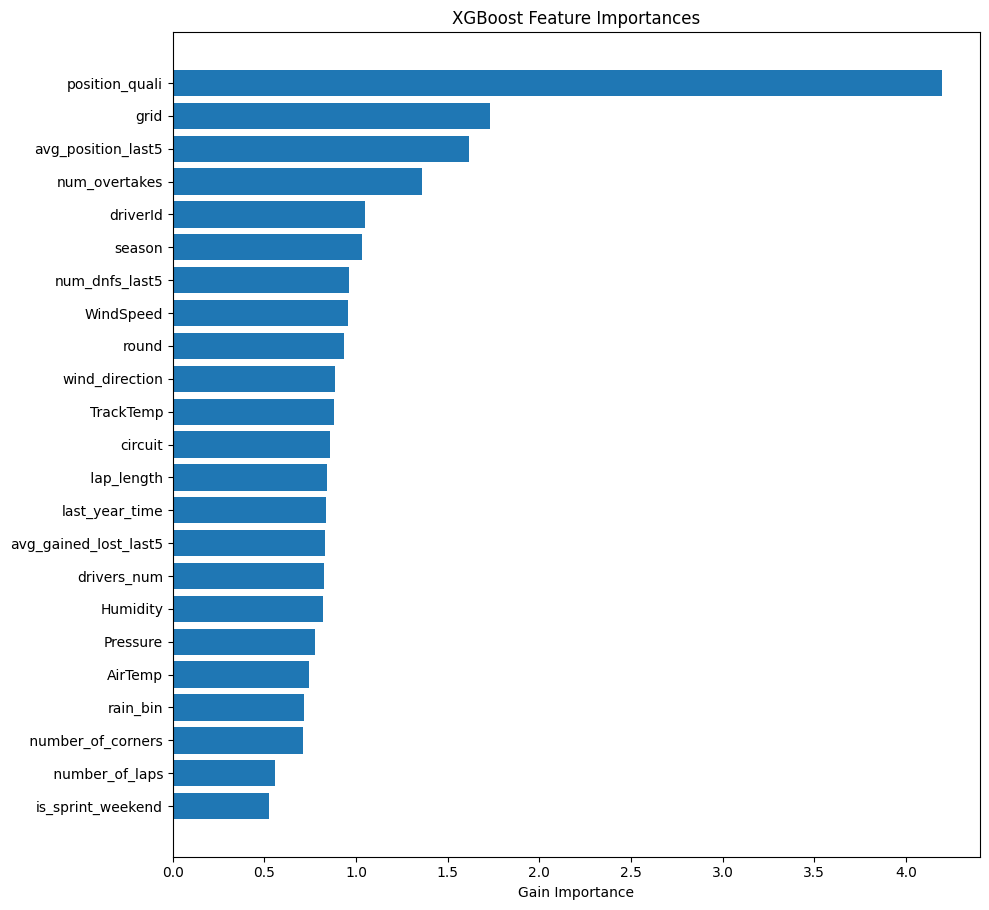

In [ ]:
import matplotlib.pyplot as plt

# feature importances
importances = model.get_score(importance_type='gain')  # 'weight', 'cover', 'total_gain', 'total_cover'

# konvertovanje u sortiran df
importance_df = pd.DataFrame({
    "Feature": list(importances.keys()),
    "Importance": list(importances.values())
}).sort_values(by="Importance", ascending=False)

# Print feature importances
# print(importance_df)

# plotovanje
plt.figure(figsize=(10, len(importance_df) * 0.4))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Gain Importance")
plt.title("XGBoost Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
print(X_train.columns.tolist())
print(f"Total features in dataset: {X_train.shape[1]}")

['season', 'round', 'drivers_num', 'position_quali', 'grid', 'driverId', 'circuit', ' lap_length', ' number_of_laps', ' number_of_corners', 'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed', 'rain_bin', 'wind_direction', 'is_sprint_weekend', 'last_year_time', 'avg_position_last5', 'num_dnfs_last5', 'avg_gained_lost_last5', 'num_overtakes']
Total features in dataset: 23


In [ ]:
used_features = list(model.get_score(importance_type='gain').keys())
print(f"Features used by model: {len(used_features)}")
print(f"Unused features: {set(X_train.columns) - set(used_features)}")

Features used by model: 23
Unused features: set()


In [ ]:
some_race_id = df_test['group_id'].unique()[] #14

# Izdvajanje jedne trke
race_df = df_test[df_test['group_id'] == some_race_id].copy()

# Predikcija plasmana
race_df['predicted_rank'] = race_df['pred_score'].rank(ascending=False, method='first')
race_df['true_rank'] = race_df['position_race']

# Sortiranje po predikciji
race_df = race_df.sort_values('predicted_rank')

# Tabela stvarne vs predvidjene vredvosti, i pred score
display_columns = ['drivers_num', 'position_quali', 'predicted_rank', 'true_rank', 'pred_score']
print(f'Rezultati za trku: {some_race_id}')
print(race_df[display_columns])

Rezultati za trku: 2024_9
      drivers_num  position_quali  predicted_rank  true_rank  pred_score
2436           33               2             1.0          1    0.120845
2430           81               4             2.0          5    0.095998
2437           63               1             3.0          3    0.095261
2435            4               3             4.0          2    0.087969
2428           44               7             5.0          4    0.067645
2421           55              12             6.0         16    0.055137
2427           14               6             7.0          6    0.018247
2431            3               5             8.0          8    0.011843
2429           16              11             9.0         19    0.008919
2432           18               9            10.0          7    0.008100
2433           22               8            11.0         14    0.004148
2434           23              10            12.0         17   -0.003377
2425           11        

In [ ]:
race_df.columns

Index(['season', 'round', 'drivers_num', 'position_quali', 'position_race',
       'grid', 'driverId', 'circuit', ' lap_length', ' number_of_laps',
       ' number_of_corners', 'AirTemp', 'Humidity', 'Pressure', 'TrackTemp',
       'WindSpeed', 'rain_bin', 'wind_direction', 'is_sprint_weekend',
       'last_year_time', 'avg_position_last5', 'num_dnfs_last5',
       'avg_gained_lost_last5', 'num_overtakes', 'group_id', 'pred_score',
       'predicted_rank', 'true_rank'],
      dtype='object')